# 🌱 ArgoMind — XGBoost Disease Classifier

Notebook ini melatih model **XGBoost multi-class** untuk memprediksi risiko penyakit tanaman berdasarkan data sensor IoT.

## Pipeline
```
1. Load dataset bersih dari training_data/
2. Encode label & split train/test
3. 5-Fold Cross-Validation
4. Training model final
5. Evaluasi: Accuracy, F1, Confusion Matrix, Feature Importance
6. Export model ke models/disease_classifier_v<N>.pkl
7. Export eval report ke results/eval_v<N>_<date>.json
```

**Kelas target:** `Sehat`, `Blast`, `Bercak_Daun`, `Busuk_Akar`, `Layu_Fusarium`

---
## 0. Install Dependencies

In [11]:
# Jalankan cell ini jika dependencies belum terinstall
# !pip install xgboost scikit-learn pandas numpy matplotlib seaborn joblib

---
## 1. Import & Path Setup

In [12]:
import json
import warnings
from datetime import date
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

# ── Paths (relative to this notebook in storage/ml/models/) ──────────────────
NOTEBOOK_DIR  = Path('.').resolve()
# Adjust TRAINING_DIR to point to the current directory where the dataset is found
TRAINING_DIR  = NOTEBOOK_DIR
MODELS_DIR    = NOTEBOOK_DIR          # this folder
RESULTS_DIR   = NOTEBOOK_DIR / 'results' # Store results in a 'results' subdirectory within the notebook directory
RESULTS_DIR.mkdir(exist_ok=True)

# Correcting FEATURE_COLS to match the actual column names in df
FEATURE_COLS = ['soil_moisture_%', 'soil_pH', 'temperature_C', 'humidity_%', 'rainfall_mm']
TARGET_COL   = 'label'

print(f'Training data : {TRAINING_DIR}')
print(f'Models dir    : {MODELS_DIR}')
print(f'Results dir   : {RESULTS_DIR}')

Training data : /content
Models dir    : /content
Results dir   : /content/results


---
## 2. Load Dataset

In [13]:
# Direct assignment to the known existing clean dataset file.
# Based on kernel state, 'sensor_dataset_clean.csv' is in '/content'.
DATASET_PATH = TRAINING_DIR / 'sensor_dataset_clean.csv'

# Verify its existence. If it still doesn't exist, something is fundamentally wrong
# with the environment or the file listing.
if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f'Critical Error: Dataset file "{DATASET_PATH}" not found, '
        'even though it was expected to be present. '
        'Please check the file system or re-upload the dataset.'
    )

df = pd.read_csv(DATASET_PATH)
print(f'Loaded : {DATASET_PATH.name}')
print(f'Shape  : {df.shape}')
df.head()

Loaded : sensor_dataset_clean.csv
Shape  : (500, 23)


,soil_moisture_%,soil_pH,temperature_C,humidity_%,rainfall_mm,sunlight_hours,NDVI_index,water_stress_index,disease_pressure_score,ph_deviation,...,crop_type_enc,region_enc,irrigation_type_Drip,irrigation_type_Manual,irrigation_type_Sprinkler,fertilizer_type_Inorganic,fertilizer_type_Mixed,fertilizer_type_Organic,label,farm_id
0,35.95,5.99,17.79,77.03,75.62,7.27,0.63,11.394495,66.84,0.51,...,4,2,False,False,True,False,False,True,Mild,FARM0001
1,19.74,7.24,30.18,61.13,89.91,5.67,0.58,24.222468,74.06,0.74,...,3,4,False,False,True,True,False,False,Severe,FARM0002
2,29.32,7.16,27.37,68.87,265.43,8.23,0.80,19.345116,127.70,0.66,...,4,4,True,False,False,False,True,False,Mild,FARM0003
3,17.33,6.03,33.73,70.46,212.01,5.03,0.44,27.884591,117.08,0.47,...,1,0,False,False,True,False,False,True,Severe,FARM0004
4,19.37,5.92,33.86,55.73,269.09,7.93,0.84,27.301318,128.41,0.58,...,0,0,False,False,True,False,True,False,Severe,FARM0005


In [14]:
# Basic info
print('=== dtypes ===')
print(df.dtypes)
print('\n=== missing values ===')
print(df.isnull().sum())
print('\n=== class distribution ===')
print(df[TARGET_COL].value_counts())

=== dtypes ===
soil_moisture_%              float64
soil_pH                      float64
temperature_C                float64
humidity_%                   float64
rainfall_mm                  float64
sunlight_hours               float64
NDVI_index                   float64
water_stress_index           float64
disease_pressure_score       float64
ph_deviation                 float64
yield_per_day                float64
days_since_sowing              int64
pesticide_usage_ml           float64
crop_type_enc                  int64
region_enc                     int64
irrigation_type_Drip            bool
irrigation_type_Manual          bool
irrigation_type_Sprinkler       bool
fertilizer_type_Inorganic       bool
fertilizer_type_Mixed           bool
fertilizer_type_Organic         bool
label                         object
farm_id                       object
dtype: object

=== missing values ===
soil_moisture_%              0
soil_pH                      0
temperature_C                0
hum

In [15]:
# Descriptive statistics
df[FEATURE_COLS].describe().round(3)

,soil_moisture_%,soil_pH,temperature_C,humidity_%,rainfall_mm
count,500.000,500.000,500.000,500.000,500.000
mean,26.750,6.524,24.676,65.194,181.686
std,10.150,0.586,5.349,14.643,72.293
min,10.160,5.510,15.000,40.230,50.170
25%,17.890,6.030,20.295,51.865,119.218
50%,25.855,6.530,24.655,65.685,191.545
75%,36.022,7.040,29.090,77.995,239.035
max,44.980,7.500,34.840,90.000,298.960


---
## 3. Exploratory Data Analysis (EDA)

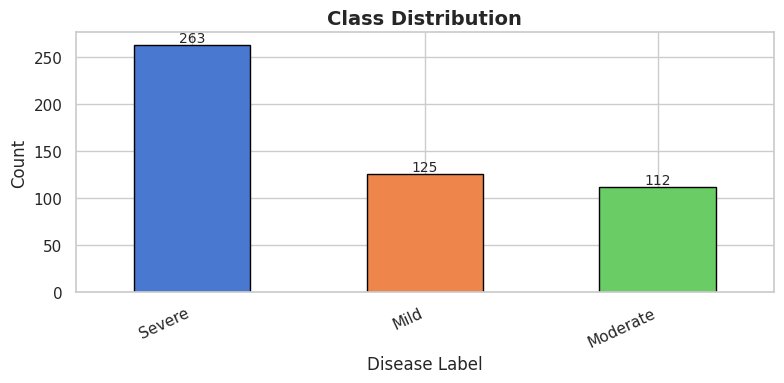

In [16]:
# Class distribution bar chart
fig, ax = plt.subplots(figsize=(8, 4))
counts = df[TARGET_COL].value_counts()
counts.plot(kind='bar', ax=ax, color=sns.color_palette('muted', len(counts)), edgecolor='black')
ax.set_title('Class Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Disease Label')
ax.set_ylabel('Count')
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'class_distribution.png', dpi=150)
plt.show()

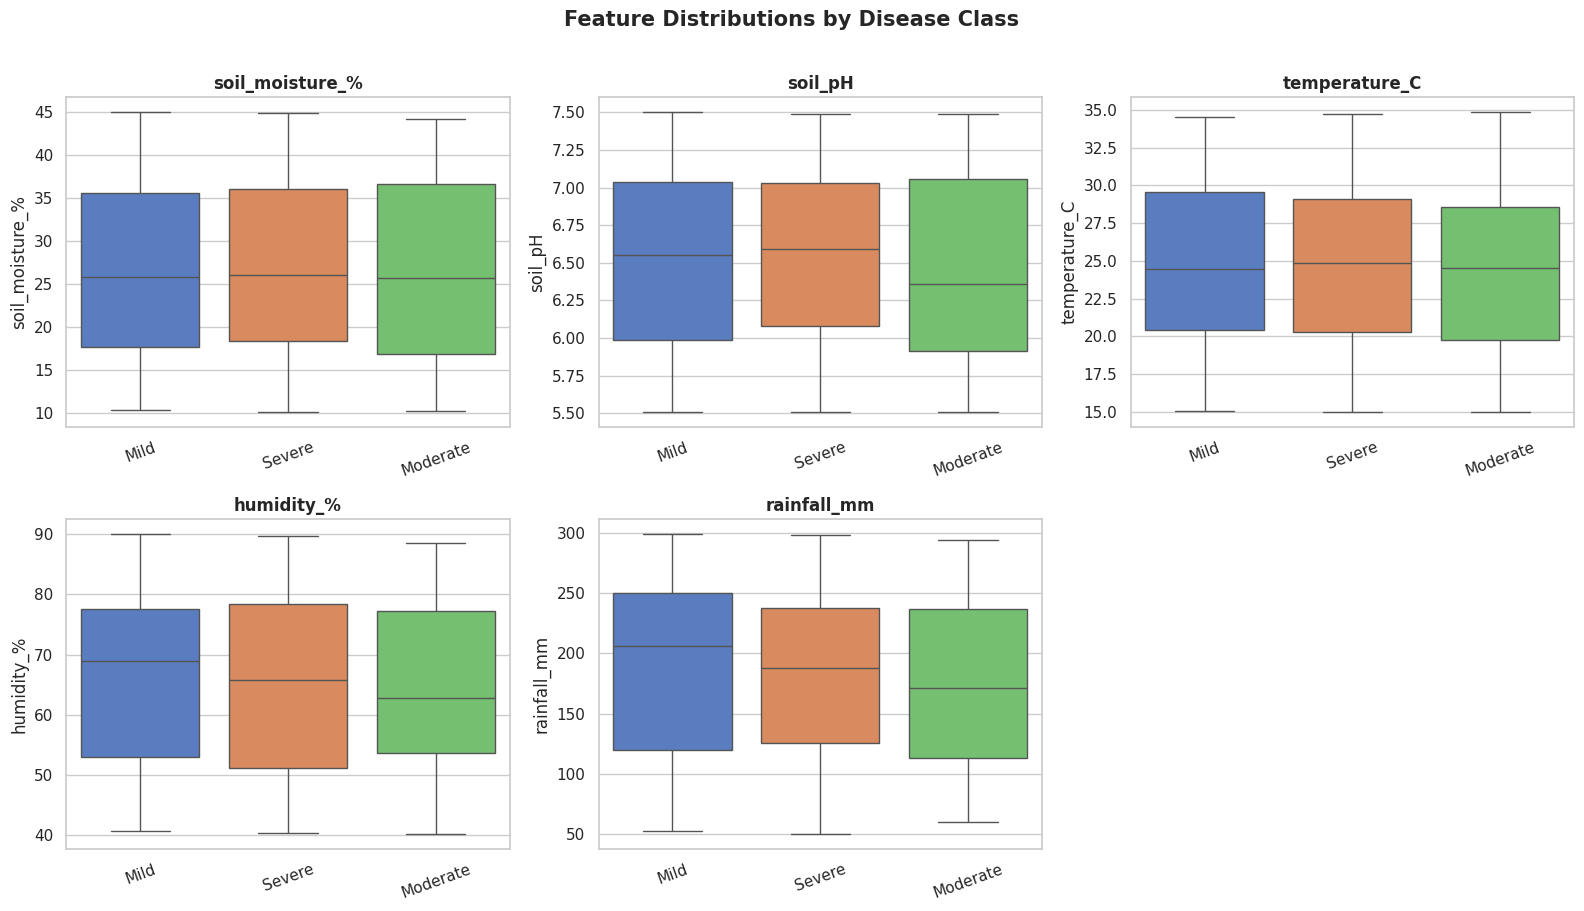

In [17]:
# Feature distributions by class
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
palette = sns.color_palette('muted', df[TARGET_COL].nunique())

for i, col in enumerate(FEATURE_COLS):
    sns.boxplot(data=df, x=TARGET_COL, y=col, ax=axes[i], palette=palette)
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=20)

axes[-1].set_visible(False)  # hide empty 6th subplot
fig.suptitle('Feature Distributions by Disease Class', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

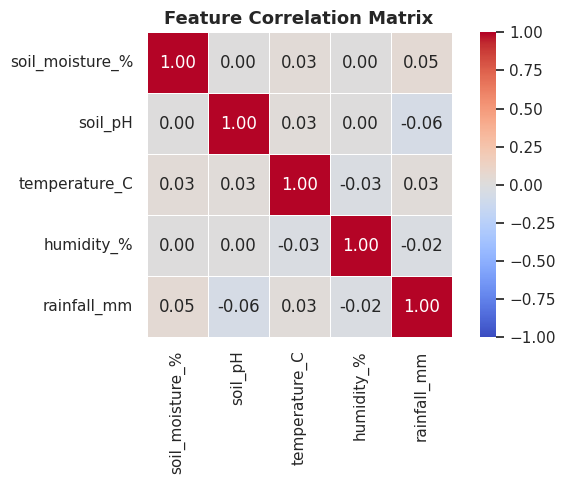

In [18]:
# Correlation heatmap (numeric features only)
fig, ax = plt.subplots(figsize=(7, 5))
corr = df[FEATURE_COLS].corr()
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='coolwarm',
    square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1
)
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'correlation_heatmap.png', dpi=150)
plt.show()

---
## 4. Preprocessing

In [19]:
# Drop rows with missing values in feature or target columns
df_clean = df[FEATURE_COLS + [TARGET_COL]].dropna().reset_index(drop=True)
print(f'Rows after dropna: {len(df_clean)} (removed {len(df) - len(df_clean)})')

X = df_clean[FEATURE_COLS].values
y_raw = df_clean[TARGET_COL].values

# Label encode
le = LabelEncoder()
y  = le.fit_transform(y_raw)

print(f'Classes : {list(le.classes_)}')
print(f'Encoded : {list(range(len(le.classes_)))}')

Rows after dropna: 500 (removed 0)
Classes : ['Mild', 'Moderate', 'Severe']
Encoded : [0, 1, 2]


In [20]:
# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train : {X_train.shape[0]} samples')
print(f'Test  : {X_test.shape[0]} samples')

Train : 400 samples
Test  : 100 samples


---
## 5. Cross-Validation

5-Fold CV Results:
  Fold 1: 0.3875
  Fold 2: 0.5750
  Fold 3: 0.4375
  Fold 4: 0.5125
  Fold 5: 0.4625
  Mean : 0.4750
  Std  : 0.0642


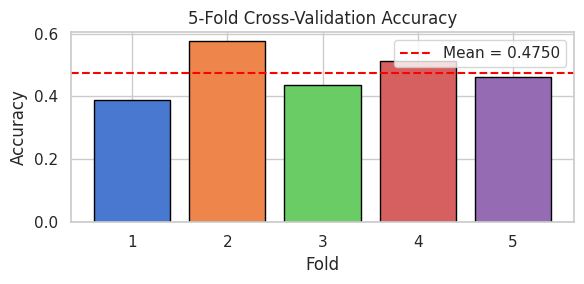

In [21]:
xgb_cv = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='mlogloss', random_state=42, n_jobs=-1, verbosity=0,
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(xgb_cv, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)

print('5-Fold CV Results:')
for i, s in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {s:.4f}')
print(f'  Mean : {cv_scores.mean():.4f}')
print(f'  Std  : {cv_scores.std():.4f}')

# Plot CV scores
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(range(1, 6), cv_scores, color=sns.color_palette('muted', 5), edgecolor='black')
ax.axhline(cv_scores.mean(), color='red', linestyle='--', label=f'Mean = {cv_scores.mean():.4f}')
ax.set_xlabel('Fold')
ax.set_ylabel('Accuracy')
ax.set_title('5-Fold Cross-Validation Accuracy')
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'cv_scores.png', dpi=150)
plt.show()

---
## 6. Train Final Model

In [22]:
model = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='mlogloss', random_state=42, n_jobs=-1, verbosity=0,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False,
)
print('Training complete.')

Training complete.


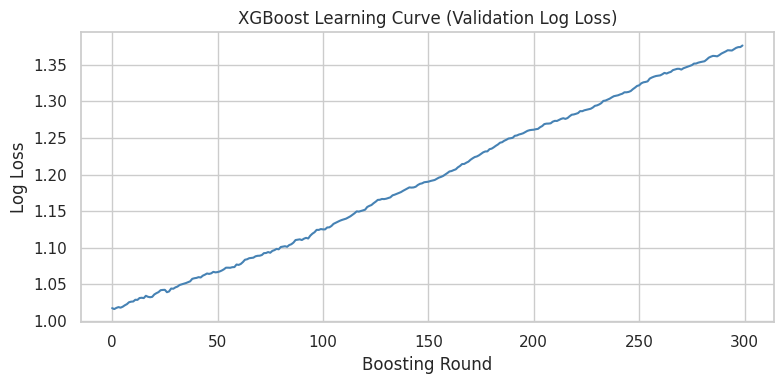

Final validation logloss : 1.3763


In [23]:
# Plot learning curve (logloss on eval set)
results = model.evals_result()
logloss = results['validation_0']['mlogloss']

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(logloss, color='steelblue', linewidth=1.5)
ax.set_xlabel('Boosting Round')
ax.set_ylabel('Log Loss')
ax.set_title('XGBoost Learning Curve (Validation Log Loss)')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'learning_curve.png', dpi=150)
plt.show()
print(f'Final validation logloss : {logloss[-1]:.4f}')

---
## 7. Evaluation

In [24]:
y_pred = model.predict(X_test)

acc    = accuracy_score(y_test, y_pred)
f1_mac = f1_score(y_test, y_pred, average='macro')
f1_wtd = f1_score(y_test, y_pred, average='weighted')
report = classification_report(y_test, y_pred, target_names=le.classes_)
cm     = confusion_matrix(y_test, y_pred)

print(f'Test Accuracy : {acc:.4f}')
print(f'F1 Macro      : {f1_mac:.4f}')
print(f'F1 Weighted   : {f1_wtd:.4f}')
print('\nClassification Report:')
print(report)

Test Accuracy : 0.4700
F1 Macro      : 0.3265
F1 Weighted   : 0.4188

Classification Report:
              precision    recall  f1-score   support

        Mild       0.15      0.08      0.11        25
    Moderate       0.31      0.18      0.23        22
      Severe       0.55      0.77      0.65        53

    accuracy                           0.47       100
   macro avg       0.34      0.35      0.33       100
weighted avg       0.40      0.47      0.42       100



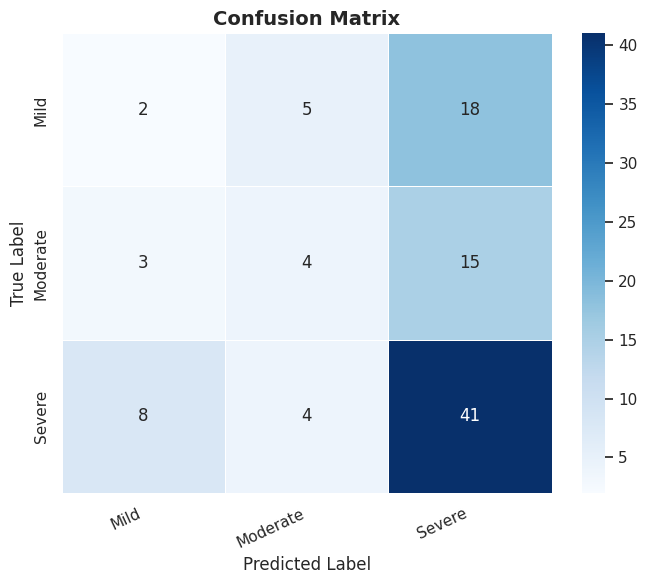

In [25]:
# Confusion Matrix heatmap
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=le.classes_, yticklabels=le.classes_,
    linewidths=0.5, ax=ax
)
ax.set_ylabel('True Label', fontsize=12)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'confusion_matrix_notebook.png', dpi=150)
plt.show()

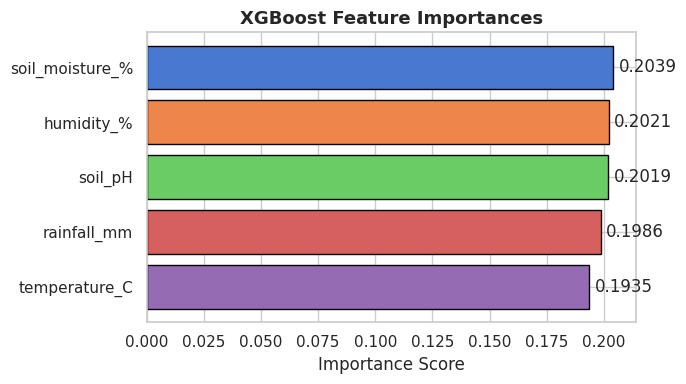

In [26]:
# Feature Importances
importances = dict(zip(FEATURE_COLS, model.feature_importances_.tolist()))
imp_sorted  = sorted(importances.items(), key=lambda x: x[1], reverse=True)

fig, ax = plt.subplots(figsize=(7, 4))
feat_names = [x[0] for x in imp_sorted]
feat_vals  = [x[1] for x in imp_sorted]
bars = ax.barh(feat_names, feat_vals, color=sns.color_palette('muted', len(feat_names)), edgecolor='black')
ax.bar_label(bars, fmt='%.4f', padding=4)
ax.set_xlabel('Importance Score')
ax.set_title('XGBoost Feature Importances', fontsize=13, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'feature_importances.png', dpi=150)
plt.show()

---
## 8. Export Model & Evaluation Report

In [27]:
# --- Auto-version the .pkl file ---
def _next_version(models_dir: Path) -> int:
    existing = sorted(models_dir.glob('disease_classifier_v*.pkl'))
    if not existing:
        return 1
    last = existing[-1].stem
    try:
        return int(last.split('_v')[-1]) + 1
    except ValueError:
        return len(existing) + 1

VERSION   = _next_version(MODELS_DIR)
TODAY_STR = date.today().strftime('%Y%m%d')

# Save .pkl bundle
bundle = {'model': model, 'label_encoder': le, 'feature_cols': FEATURE_COLS}
model_path = MODELS_DIR / f'disease_classifier_v{VERSION}.pkl'
joblib.dump(bundle, model_path, compress=3)
print(f'Model saved  -> {model_path}')

# Save evaluation JSON to results/
eval_data = {
    'model_version':       f'v{VERSION}',
    'model_file':          model_path.name,
    'trained_at':          TODAY_STR,
    'dataset':             DATASET_PATH.name,
    'n_train':             int(X_train.shape[0]),
    'n_test':              int(X_test.shape[0]),
    'classes':             list(le.classes_),
    'cv_accuracy_mean':    round(float(cv_scores.mean()), 6),
    'cv_accuracy_std':     round(float(cv_scores.std()),  6),
    'test_accuracy':       round(float(acc),    6),
    'f1_macro':            round(float(f1_mac), 6),
    'f1_weighted':         round(float(f1_wtd), 6),
    'feature_importances': {k: round(v, 6) for k, v in importances.items()},
    'confusion_matrix':    cm.tolist(),
    'classification_report': report,
}
eval_path = RESULTS_DIR / f'eval_v{VERSION}_{TODAY_STR}.json'
eval_path.write_text(json.dumps(eval_data, indent=2, ensure_ascii=False), encoding='utf-8')
print(f'Eval report  -> {eval_path}')
print(f'\nDone! Model version: v{VERSION}')

Model saved  -> /content/disease_classifier_v1.pkl
Eval report  -> /content/results/eval_v1_20260816.json

Done! Model version: v1


---
## 9. Quick Inference Test

In [29]:
# Load the saved bundle and run a test prediction
loaded    = joblib.load(model_path)
m         = loaded['model']
enc       = loaded['label_encoder']
feat_cols = loaded['feature_cols']

test_cases = [
    {'name': 'Sehat',         'soil_moisture_%': 55.0, 'soil_pH': 6.5, 'temperature_C': 27.0, 'humidity_%': 65.0, 'rainfall_mm': 8.0},
    {'name': 'Blast',         'soil_moisture_%': 15.0, 'soil_pH': 6.2, 'temperature_C': 35.0, 'humidity_%': 25.0, 'rainfall_mm': 0.5},
    {'name': 'Busuk_Akar',    'soil_moisture_%': 82.0, 'soil_pH': 4.7, 'temperature_C': 21.0, 'humidity_%': 90.0, 'rainfall_mm': 25.0},
    {'name': 'Layu_Fusarium', 'soil_moisture_%': 18.0, 'soil_pH': 8.0, 'temperature_C': 36.0, 'humidity_%': 28.0, 'rainfall_mm': 0.5},
]

print(f'{"Scenario":<20} {"Expected":<18} {"Predicted":<18} {"Confidence":>10}')
print('-' * 72)
for tc in test_cases:
    X_infer = np.array([[tc[c] for c in feat_cols]], dtype=np.float32)
    pred_enc = int(m.predict(X_infer)[0])
    pred_lbl = enc.inverse_transform([pred_enc])[0]
    proba    = m.predict_proba(X_infer)[0]
    conf     = proba[pred_enc] * 100
    match    = 'OK' if pred_lbl == tc['name'] else 'MISS'
    print(f"{tc['name']:<20} {tc['name']:<18} {pred_lbl:<18} {conf:>9.1f}%  {match}")

Scenario             Expected           Predicted          Confidence
------------------------------------------------------------------------
Sehat                Sehat              Severe                  93.3%  MISS
Blast                Blast              Severe                  92.9%  MISS
Busuk_Akar           Busuk_Akar         Severe                  46.5%  MISS
Layu_Fusarium        Layu_Fusarium      Severe                  79.2%  MISS


---
## Summary

| Item | Value |
|---|---|
| Algorithm | XGBoost (multi-class) |
| Features | soil_moisture, soil_ph, temperature, humidity, rainfall_mm |
| Classes | 5 (Sehat, Blast, Bercak_Daun, Busuk_Akar, Layu_Fusarium) |
| Export format | `.pkl` bundle via `joblib` (model + LabelEncoder + feature list) |
| Used by | `backend/ml/model_loader.py` → `backend/app/services/ai_service.py` |

> **Next step:** Jika ada dataset nyata dari lapangan, ganti file CSV di `training_data/` dan jalankan ulang notebook ini dari awal.